### Project: Titanic Machine Learning from Disaster

In [80]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [81]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

Notes:
* SipSp: of siblings/ spouses abroad the Titanic
* Parch: of parents/ children abroad the Titanic
* Ticket: Ticket number
* Cabin: Cabin number

In [82]:
train_df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [83]:
# PassengerId not useful for prediction, so we can drop it from the training and test datasets.
train_df.set_index('PassengerId', inplace=True)

In [84]:
train_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [85]:
test_df.set_index('PassengerId', inplace=True)
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S



1. Feature Classification: Categorical vs Numerical
* help select the appropriate plots for visualization.

Which features are categorical?
* Categorical Features: nominal, ordinal, ratio, interval
* To classify the samples into sets of similar samples

Which features are numerical?
* Numerical features: discrete, contnuous, or timeseries 
* These values change from sample to sample

In [86]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [87]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


- Categorical: Survival, Sex, embarked, Pclass(ordinal), SibSp, Parch
- Numerical: (continuous)Age, Fare
- Mix types of data: Ticket, Cabin
- Contain Error/Typo : Name
- Blank or Null: Cabin > Age > Embarked
- Various Data Type: String, Int, Float

In [88]:
# chuyen doi kieu du  lieu cac cot sau khi da xac dinh duoc cac cot nao la categorical va cot nao la numerical
train_df[["Survived", "Sex", "Pclass", "SibSp", "Parch", "Enbarked"]] = train_df[["Survived", "Sex", "Pclass", "SibSp", "Parch", "Embarked"]].astype("category")

In [89]:
test_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [90]:
test_df[[ "Sex", "Pclass", "SibSp", "Parch","Embarked"]] = test_df[["Sex", "Pclass", "SibSp", "Parch","Embarked"]].astype("category")


#### EDA (Exploreatory Data Analysis)

In [91]:
train_df.info()
# phan loai cac cot theo kieu du lieu  
# cot age va cotcabin con nhieu null

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    category
 6   Parch     891 non-null    category
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    object  
 10  Embarked  889 non-null    object  
 11  Enbarked  889 non-null    category
dtypes: category(6), float64(2), object(4)
memory usage: 55.1+ KB


Distribution of Numerical feature values across the samples

In [92]:
train_df.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


##### Correlating categorical features
- Categorical: survival, sex, embarked, pclass, sibsp, parch

In [93]:
train_df.describe(include = "category")

,Survived,Pclass,Sex,SibSp,Parch,Enbarked
count,891,891,891,891,891,889
unique,2,3,2,7,7,3
top,0,3,male,0,0,S
freq,549,491,577,608,678,644


<Axes: xlabel='Survived'>

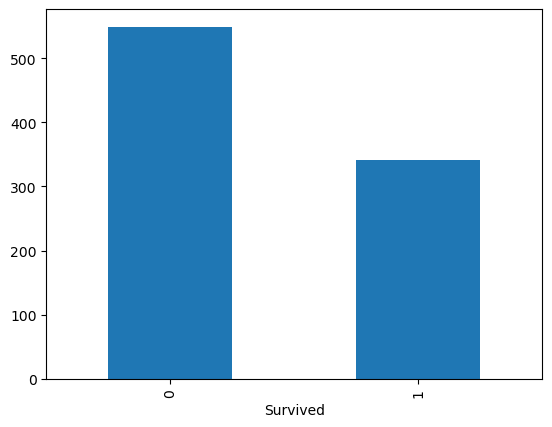

In [94]:
figure_survived = train_df['Survived'].value_counts()
figure_survived.plot(kind = "bar")

In [95]:
figure_survived = train_df['Survived'].value_counts(normalize = True)
figure_survived
## only 38% of the passengers survived, so the dataset is imbalanced. We will need to take this into account when we build our model.

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [96]:
train_df.Sex.value_counts(normalize = True)

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [97]:
related = train_df[['Survived', 'Sex']].groupby("Survived").value_counts()
related = related.to_frame()
related

C:\Users\admin\AppData\Local\Temp\ipykernel_11120\4159854769.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  related = train_df[['Survived', 'Sex']].groupby("Survived").value_counts()


count
Survived Sex          
0        male      468
         female     81
1        female    233
         male      109

In [98]:
related = train_df[['Survived', 'Sex']].groupby("Sex").value_counts(normalize = True)
related = related.to_frame()
related

C:\Users\admin\AppData\Local\Temp\ipykernel_11120\314194684.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  related = train_df[['Survived', 'Sex']].groupby("Sex").value_counts(normalize = True)


proportion
Sex    Survived            
female 1           0.742038
       0           0.257962
male   0           0.811092
       1           0.188908

<Axes: xlabel='Sex,Survived'>

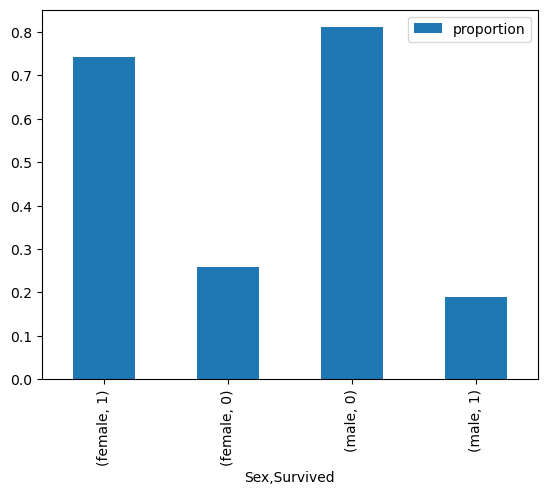

In [99]:
related.plot(kind = "bar")
# nam gioi co ti le song thap hon nu gioi du nhieu nguoi hon

<Axes: xlabel='Sex', ylabel='count'>

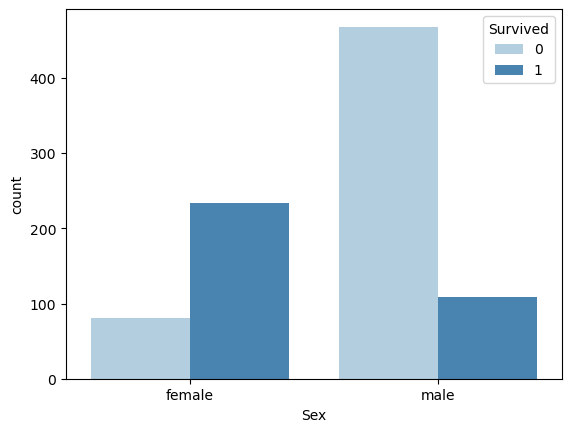

In [100]:
sns.countplot(data = train_df, x = 'Sex', hue = "Survived", palette= "Blues")

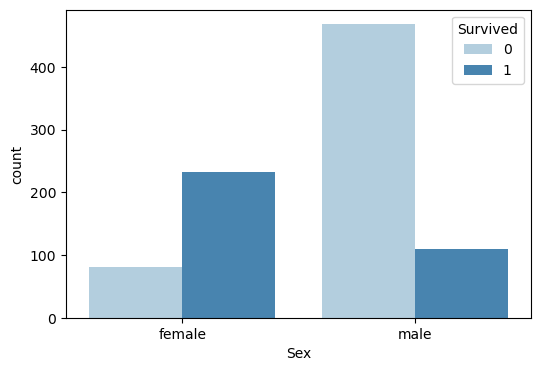

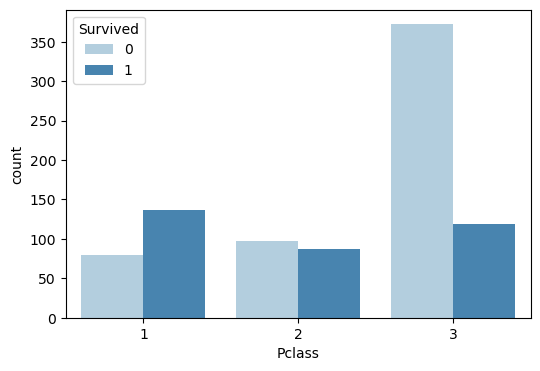

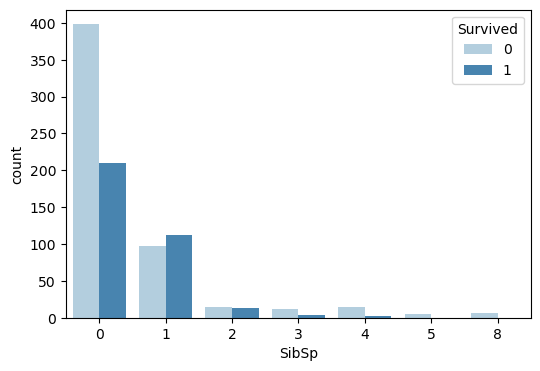

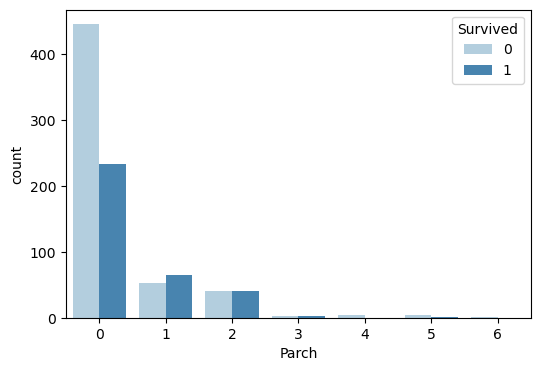

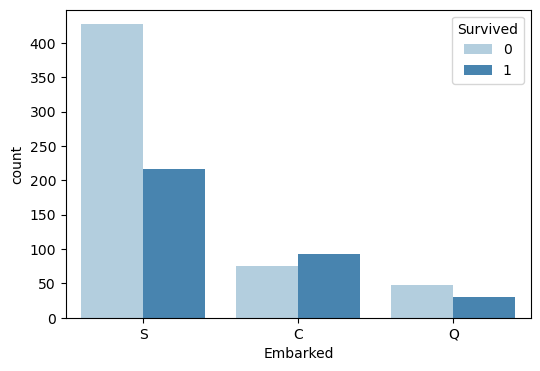

In [101]:
sup = train_df[["Sex", "Pclass", "SibSp", "Parch", "Embarked"]]
for i in sup :
    plt.figure(figsize = (6,4))
    sns.countplot(data = train_df, x = i, hue = "Survived", palette = "Blues")

Observation:
- Survival rate: 
    * male < female
    * Pclass 3 < 2 < 1 ( the higher class, the higher survival)
    * Genaraly take a trip with family or Sib has higher rating, family has 1-2 members has higher chances of survival
    * Embarked S < Q < C for survival rate


#### EDA for Numerical Features
 * Numerical features: Age, Fare

In [102]:
train_df[["Age", "Fare"]]

,Age,Fare
PassengerId,,
1,22.0,7.2500
2,38.0,71.2833
3,26.0,7.9250
4,35.0,53.1000
5,35.0,8.0500
...,...,...
887,27.0,13.0000
888,19.0,30.0000
889,NaN,23.4500


<Axes: xlabel='Age', ylabel='Count'>

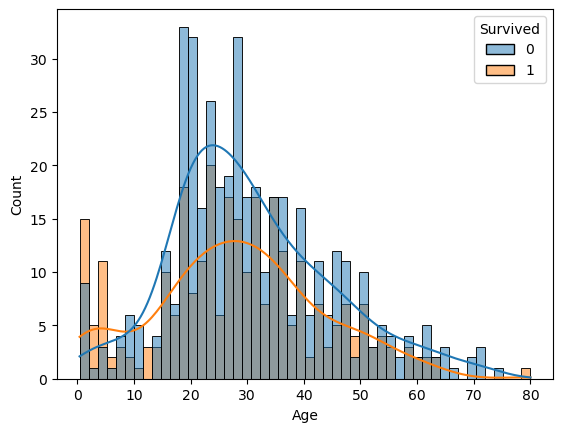

In [103]:
sns.histplot(data = train_df, x = "Age",bins = 50, kde = True, hue = "Survived")
# Age impact to survival
# small people and old one are priotized

In [104]:
train_df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Count'>

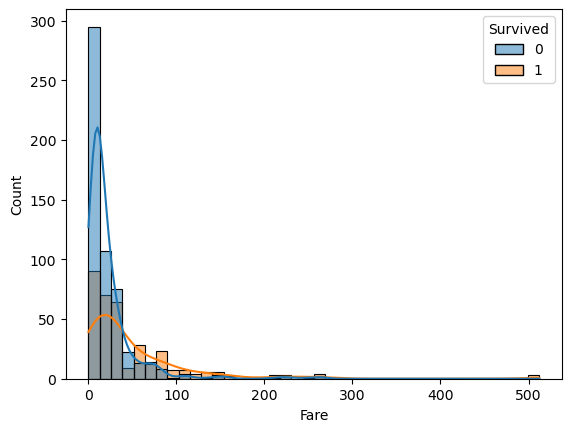

In [105]:
sns.histplot(data = train_df, x = "Fare", bins = 40, kde = True, hue = "Survived")
# higher fee, money you spent on ticket that you are higher class, higher you survived

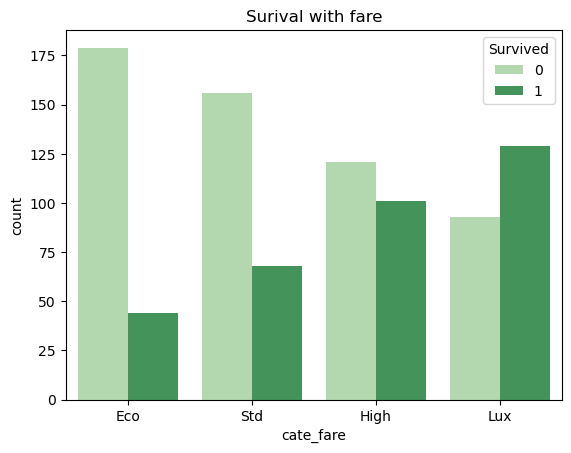

In [106]:
fare_cate = ["Eco", "Std", "High", "Lux"]
train_df["cate_fare"] = pd.qcut(train_df["Fare"], 4, labels = fare_cate)
sns.countplot(data = train_df, x = "cate_fare", hue = "Survived", palette= "Greens");
plt.title("Surival with fare");

#### Feature Enginerring and Data Wrangling
Name


In [107]:
train_df["Name"].head()

PassengerId
1                              Braund, Mr. Owen Harris
2    Cumings, Mrs. John Bradley (Florence Briggs Th...
3                               Heikkinen, Miss. Laina
4         Futrelle, Mrs. Jacques Heath (Lily May Peel)
5                             Allen, Mr. William Henry
Name: Name, dtype: object

In [108]:
import re # regular expression
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

train_df["Title"] = train_df["Name"].apply(get_title)
train_df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [109]:
temp = train_df[["Title", "Survived"]].groupby('Title').value_counts(normalize = True)
temp = temp.to_frame()
temp

proportion
Title    Survived            
Capt     0           1.000000
         1           0.000000
Col      0           0.500000
         1           0.500000
Countess 1           1.000000
         0           0.000000
Don      0           1.000000
         1           0.000000
Dr       0           0.571429
         1           0.428571
Jonkheer 0           1.000000
         1           0.000000
Lady     1           1.000000
         0           0.000000
Major    0           0.500000
         1           0.500000
Master   1           0.575000
         0           0.425000
Miss     1           0.697802
         0           0.302198
Mlle     1           1.000000
         0           0.000000
Mme      1           1.000000
         0           0.000000
Mr       0           0.843327
         1           0.156673
Mrs      1           0.792000
         0           0.208000
Ms       1           1.000000
         0           0.000000
Rev      0           1.000000
         1           0.000000
Sir      1           1.000000
         0           0.000000

<Axes: xlabel='Title', ylabel='count'>

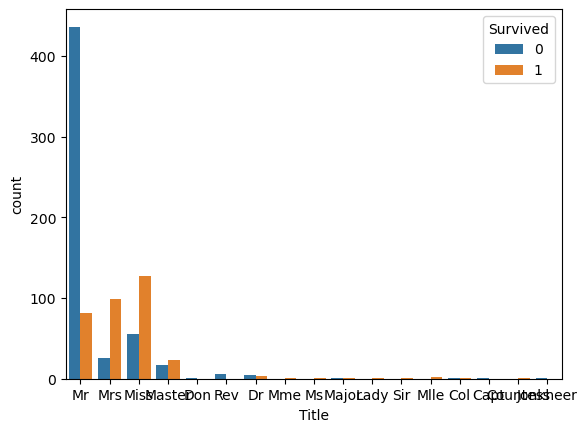

In [110]:
sns.countplot(data=train_df, x="Title", hue="Survived")

In [134]:
def group_title(title):
    if title in ["Mr", "Miss", "Mrs", "Master"]:
        return title
    elif title == "Ms":
        return "Miss"
    else:
        return "Other"
train_df["Title"] = train_df["Title"].apply(group_title)
# do the same for the test dataset
test_df["Title"] = test_df["Name"].apply(get_title)
test_df["Title"] = test_df["Title"].apply(group_title)


<Axes: xlabel='Title', ylabel='count'>

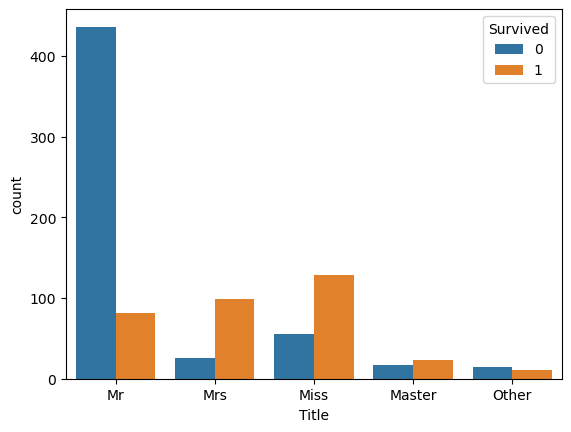

In [112]:
sns.countplot(data=train_df, x="Title", hue="Survived")

Family
* SibSp, Parch

In [113]:
train_df["family_size"] = train_df["SibSp"].astype(int) + train_df["Parch"].astype(int) + 1
test_df["family_size"] = test_df["SibSp"].astype(int) + test_df["Parch"].astype(int) + 1

In [114]:
def group_family_size(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small"
    else:
        return "Large"
train_df["family_size"] = train_df["family_size"].apply(group_family_size)

<Axes: xlabel='family_size', ylabel='count'>

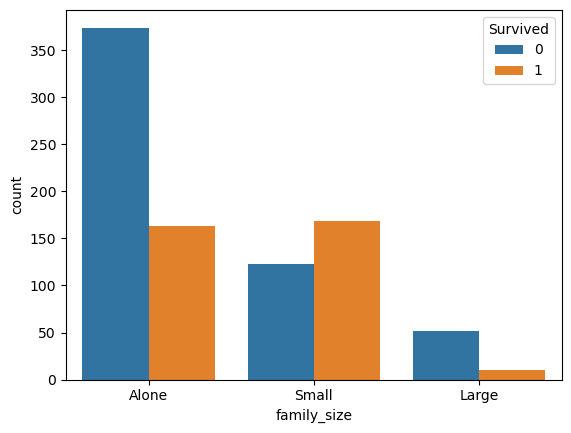

In [115]:
sns.countplot(data=train_df, x="family_size", hue="Survived",order = ["Alone", "Small", "Large"])

Data wrangling

In [131]:
num_features = ["Age", "Fare"]
cat_features = ["Sex", "Pclass", "Embarked", 'Title', 'family_size']
features_cols = num_features + cat_features

In [117]:
# what col has null values
train_df.info()
# -> Age and Cabin have null values

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Survived     891 non-null    category
 1   Pclass       891 non-null    category
 2   Name         891 non-null    object  
 3   Sex          891 non-null    category
 4   Age          714 non-null    float64 
 5   SibSp        891 non-null    category
 6   Parch        891 non-null    category
 7   Ticket       891 non-null    object  
 8   Fare         891 non-null    float64 
 9   Cabin        204 non-null    object  
 10  Embarked     889 non-null    object  
 11  Enbarked     889 non-null    category
 12  cate_fare    891 non-null    category
 13  Title        891 non-null    object  
 14  family_size  891 non-null    object  
dtypes: category(7), float64(2), object(6)
memory usage: 70.1+ KB


Filling missing values
- Filling Age missing values with median-group features

In [118]:
train_df.groupby(['Sex', 'Pclass'])["Age"].median()

C:\Users\admin\AppData\Local\Temp\ipykernel_11120\7401992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Sex', 'Pclass'])["Age"].median()


Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [121]:
train_df['Age'] = train_df['Age'].fillna(train_df.groupby(['Sex', 'Pclass'])['Age'].transform('median'))

C:\Users\admin\AppData\Local\Temp\ipykernel_11120\1081509725.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df['Age'] = train_df['Age'].fillna(train_df.groupby(['Sex', 'Pclass'])['Age'].transform('median'))


In [125]:
train_df.groupby(['Sex', 'Pclass'])["Age"].transform('median')

C:\Users\admin\AppData\Local\Temp\ipykernel_11120\3554292823.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Sex', 'Pclass'])["Age"].transform('median')


PassengerId
1      27.0
2      25.5
3      27.0
4      25.5
5      27.0
       ... 
887    25.0
888    25.5
889    27.0
890    25.0
891    27.0
Name: Age, Length: 891, dtype: float64

In [126]:
test_df['Age'] = test_df['Age'].fillna(test_df.groupby(['Sex', 'Pclass'])['Age'].transform('median'))

C:\Users\admin\AppData\Local\Temp\ipykernel_11120\2493897313.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df['Age'] = test_df['Age'].fillna(test_df.groupby(['Sex', 'Pclass'])['Age'].transform('median'))


In [129]:
test_df.isnull().sum()

Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
family_size      0
dtype: int64

In [132]:
X = train_df[features_cols]
y = train_df["Survived"]

In [135]:
X_test = test_df[features_cols]

In [136]:
# preprocess pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

In [137]:
preprocessor.fit(X)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [138]:
X = preprocessor.transform(X)
X_test = preprocessor.transform(X_test)

In [139]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)